# SmolLM3-3B Medical QA — Evaluation Notebook

Loads the fine-tuned model **`jubayer009/huggingface-smolLm3b`** from the Hugging Face
Hub and evaluates it on the held-out test set (`Test_Dataset_Prepare_STG.json`, 136
patient-query -> doctor-response pairs).

**Metrics computed:**

*Generation-quality metrics (computed directly on generated text vs. reference text):*
- BLEU
- ROUGE-1 / ROUGE-2 / ROUGE-L
- METEOR
- BERTScore
- BLEURT
- Cosine Similarity (sentence-embedding based)
- Exact Match (EM)

*Classification-style metrics (Accuracy, Precision, Recall/Sensitivity, Specificity, F1):*

These five are inherently classification metrics (they need a confusion matrix), but our
model's output is free-text, not a class label. So we derive a well-defined binary task
from the generations, called **semantic-match classification**:

1. For every test item we have a *true pair* — (model's generated response, its correct
   reference response) — which should be semantically similar → label **1**.
2. We also build a *false pair* for every item by pairing the model's generated response
   with a *different, randomly-selected* reference response from elsewhere in the test set
   → label **0**.
3. We embed every response with a sentence-embedding model and compute cosine similarity
   for every pair. A pair is **predicted a match (1)** if its similarity is above a
   threshold (the midpoint between the mean similarity of true pairs and false pairs),
   otherwise **predicted a non-match (0)**.
4. Accuracy / Precision / Recall / Specificity / F1 are then computed on this balanced
   true-pair vs. false-pair classification task.

This is a standard way to turn a generative model's outputs into a well-posed binary
classification problem for metrics that otherwise don't apply to free text, and it
directly measures whether the model's answers are semantically closer to their *own*
correct reference than to a *random* reference.

**Pipeline:**
1. Environment setup & installs
2. Hugging Face authentication
3. Load model + tokenizer from the Hub
4. Load the test dataset
5. Generate model predictions for every test item
6. Compute generation-quality metrics (BLEU, ROUGE, METEOR, BERTScore, BLEURT, Cosine Sim, EM)
7. Build the semantic-match task and compute Accuracy / Precision / Recall / Specificity / F1
8. Results summary table + charts
9. Save everything to disk


## 1. Environment setup

In [1]:
!nvidia-smi
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  cuda:{i} ->", torch.cuda.get_device_name(i))


Sat Aug  1 10:38:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q -U "transformers>=4.51.0" "accelerate>=1.4.0" "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" "datasets>=3.2.0" "huggingface_hub>=0.27.0" sentencepiece \
    "evaluate>=0.4.0" "sacrebleu>=2.4.0" "rouge_score>=0.1.2" "nltk>=3.8.0" \
    "bert_score>=0.3.13" "sentence-transformers>=3.0.0" scikit-learn matplotlib pandas tqdm

# BLEURT isn't on PyPI as a normal release -- install straight from the GitHub repo.
!pip install -q git+https://github.com/google-research/bleurt.git

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 87.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 46.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

True

## 2. Hugging Face authentication

The merged model repo (`jubayer009/huggingface-smolLm3b`) was pushed as **private**
in the training notebook, so you need a token with at least **read** access.

- **On Kaggle:** Add-ons -> Secrets -> Add secret named `HF_TOKEN`, then this cell picks it
  up automatically.
- **Anywhere else:** it falls back to an interactive login prompt.


In [3]:
from huggingface_hub import login

hf_token = None
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    pass

if hf_token:
    login(token=hf_token)
    print("Logged in to Hugging Face Hub using Kaggle secret HF_TOKEN.")
else:
    login()  # will prompt for a token interactively


Logged in to Hugging Face Hub using Kaggle secret HF_TOKEN.


## 3. Load the fine-tuned model + tokenizer from the Hub

In [4]:
MODEL_REPO = "medalpaca/medalpaca-7b"   # merged model repo pushed in the training notebook

from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_REPO,
    dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)
model.eval()

print(f"Loaded {MODEL_REPO}")
print(f"Memory footprint: {model.get_memory_footprint() / 1e9:.2f} GB")


config.json:   0%|          | 0.00/542 [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 32000), got -1. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

...

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['pad_token_id']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Loaded medalpaca/medalpaca-7b
Memory footprint: 13.48 GB


## 4. Load the test dataset

Same `instruction` / `input` / `output` schema as the training data. Update `TEST_DATA_PATH`
if your JSON file lives somewhere else (e.g. `/kaggle/input/<dataset-name>/Test_Dataset_Prepare_STG.json`).

In [5]:
import json

TEST_DATA_PATH = "/kaggle/input/datasets/naziaa02/stg-dataset-534/STG_Medical_QA_Dataset.json"   # <-- update path if needed

with open(TEST_DATA_PATH, "r") as f:
    test_data = json.load(f)

print(f"Loaded {len(test_data)} test examples")
print(json.dumps(test_data[0], indent=2)[:800])


Loaded 534 test examples
{
  "instruction": "You are a medical doctor. Answer the following clinical question accurately and concisely according to the Standard Treatment Guidelines.",
  "input": "What are the signs and symptoms of Anaemia of pregnancy?",
  "output": "The signs and symptoms include: Increased tiredness and weakness; Pallor of the mucous membranes and nail beds; If the anaemia is severe, oedema and signs of CCF may be present."
}


## 5. Generate model predictions

Uses the exact same prompt template as training (`### Instruction: / ### Patient Query: /
### Response:`), so the model sees inputs in the same format it was fine-tuned on.

In [6]:
PROMPT_TEMPLATE = """### Instruction:
{instruction}

### Patient Query:
{input}

### Response:
"""

def build_prompt(instruction, patient_input):
    return PROMPT_TEMPLATE.format(instruction=instruction, input=patient_input)

@torch.no_grad()
def generate_response(instruction, patient_input, max_new_tokens=300):
    prompt = build_prompt(instruction, patient_input)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,          # greedy -- deterministic & reproducible for evaluation
        num_beams=1,
        pad_token_id=tokenizer.pad_token_id,
    )
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded.split("### Response:")[-1].strip()


In [7]:
from tqdm.auto import tqdm

predictions = []
references = []
inputs_list = []

for ex in tqdm(test_data, desc="Generating"):
    pred = generate_response(ex["instruction"], ex["input"])
    predictions.append(pred)
    references.append(ex["output"].strip())
    inputs_list.append(ex["input"])

print("Done. Example:")
print("-" * 60)
print("INPUT:    ", inputs_list[0][:200])
print("REFERENCE:", references[0][:200])
print("PREDICTED:", predictions[0][:200])


Generating:   0%|          | 0/534 [00:00<?, ?it/s]

Done. Example:
------------------------------------------------------------
INPUT:     What are the signs and symptoms of Anaemia of pregnancy?
REFERENCE: The signs and symptoms include: Increased tiredness and weakness; Pallor of the mucous membranes and nail beds; If the anaemia is severe, oedema and signs of CCF may be present.
PREDICTED: Anaemia of pregnancy is a condition in which the mother has a lower than normal number of red blood cells. The signs and symptoms of anemia of pregnancy include:
Fatigue and weakness Headache Irritabi


In [8]:
import pandas as pd

results_df = pd.DataFrame({
    "input": inputs_list,
    "reference": references,
    "prediction": predictions,
})
results_df.to_csv("/kaggle/working/predictions.csv", index=False)
results_df.head()


,input,reference,prediction
0,What are the signs and symptoms of Anaemia of ...,The signs and symptoms include: Increased tire...,Anaemia of pregnancy is a condition in which t...
1,When should a patient with Tonsillitis be refe...,Refer the patient: Tonsillitis accompanied by—...,"As per the Standard Treatment Guidelines, a pa..."
2,What is Postmenopausal bleeding?,Postmenopausal bleeding is bleeding after the ...,"As per the information provided, postmenopausa..."
3,What are the signs and symptoms of Acute myoca...,The signs and symptoms include: Sudden pain no...,"As per the information provided, the signs and..."
4,What are the signs and symptoms of Acute rheum...,The signs and symptoms include: Fever; Anorexi...,"As per the information provided, Acute rheumat..."


## 6. Generation-quality metrics

### 6.1 BLEU, ROUGE-1/2/L, METEOR (via `evaluate`)

In [9]:
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

bleu_result = bleu_metric.compute(predictions=predictions, references=[[r] for r in references])
rouge_result = rouge_metric.compute(predictions=predictions, references=references)
meteor_result = meteor_metric.compute(predictions=predictions, references=references)

print("BLEU:   ", bleu_result["bleu"])
print("ROUGE-1:", rouge_result["rouge1"])
print("ROUGE-2:", rouge_result["rouge2"])
print("ROUGE-L:", rouge_result["rougeL"])
print("METEOR: ", meteor_result["meteor"])


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


BLEU:    0.01834010211074868
ROUGE-1: 0.19271591477229982
ROUGE-2: 0.05040742990028036
ROUGE-L: 0.1470336710191762
METEOR:  0.1509469235054892


### 6.2 BERTScore

In [10]:
# Known incompatibility: bert_score's internal tokenizer call doesn't cap model_max_length,
# and on newer transformers/tokenizers versions the default sentinel value (~1e30) overflows
# the Rust truncation backend, raising "OverflowError: int too big to convert". Patch
# AutoTokenizer.from_pretrained to clamp model_max_length to a sane value before bert_score
# (loaded internally by evaluate's "bertscore" module) ever constructs its tokenizer.
import transformers

_original_from_pretrained = transformers.AutoTokenizer.from_pretrained.__func__

def _clamped_from_pretrained(cls, *args, **kwargs):
    tok = _original_from_pretrained(cls, *args, **kwargs)
    if getattr(tok, "model_max_length", None) and tok.model_max_length > 100_000:
        tok.model_max_length = 512
    return tok

transformers.AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)

bertscore_metric = evaluate.load("bertscore")
bertscore_result = bertscore_metric.compute(
    predictions=predictions,
    references=references,
    lang="en",
    model_type="microsoft/deberta-xlarge-mnli",
)

bertscore_precision = sum(bertscore_result["precision"]) / len(bertscore_result["precision"])
bertscore_recall = sum(bertscore_result["recall"]) / len(bertscore_result["recall"])
bertscore_f1 = sum(bertscore_result["f1"]) / len(bertscore_result["f1"])

print(f"BERTScore Precision: {bertscore_precision:.4f}")
print(f"BERTScore Recall:    {bertscore_recall:.4f}")
print(f"BERTScore F1:        {bertscore_f1:.4f}")

config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 3.04GB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.04GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB. GPU 0 has a total capacity of 14.56 GiB of which 384.81 MiB is free. Including non-PyTorch memory, this process has 14.18 GiB memory in use. Of the allocated memory 12.93 GiB is allocated by PyTorch, and 1.12 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

### 6.3 BLEURT

BLEURT needs a checkpoint download on first use (the small `BLEURT-tiny` checkpoint is
used here to keep this fast; swap in `bleurt-base-128` or `bleurt-large-512` for a more
accurate but slower score). Wrapped in a try/except since it depends on TensorFlow and a
one-time ~50-900MB checkpoint download that can occasionally fail in sandboxed
environments -- if it fails, every other metric in this notebook still runs fine.

In [11]:
bleurt_scores = None
try:
    # Google's original "bleurt" package is TensorFlow-based and its checkpoint download
    # / TF-version compatibility is fragile in sandboxed notebook environments (this is why
    # it was returning None/NaN originally). bleurt-pytorch is a drop-in, PyTorch-only
    # reimplementation that loads the same official BLEURT checkpoints via transformers --
    # but it's unmaintained and was written against an older transformers API, so it needs
    # a few small compatibility shims for the transformers version SmolLM3 requires (>=4.51.0).
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/lucadiliello/bleurt-pytorch.git"],
        check=True,
    )

    import transformers.pytorch_utils as _pytorch_utils
    import transformers.modeling_utils as _modeling_utils

    # Shim 1: find_pruneable_heads_and_indices was removed from transformers.pytorch_utils.
    if not hasattr(_pytorch_utils, "find_pruneable_heads_and_indices"):
        def find_pruneable_heads_and_indices(heads, n_heads, head_size, already_pruned_heads):
            mask = torch.ones(n_heads, head_size)
            heads = set(heads) - already_pruned_heads
            for head in heads:
                head = head - sum(1 if h < head else 0 for h in already_pruned_heads)
                mask[head] = 0
            mask = mask.view(-1).contiguous().eq(1)
            index = torch.arange(len(mask))[mask].long()
            return heads, index

        _pytorch_utils.find_pruneable_heads_and_indices = find_pruneable_heads_and_indices

    # Shim 2: get_head_mask / _convert_head_mask_to_5d were removed from PreTrainedModel as
    # part of the newer masking_utils refactor (same refactor behind the
    # get_extended_attention_mask deprecation warning you may see above).
    if not hasattr(_modeling_utils.PreTrainedModel, "get_head_mask"):
        def _convert_head_mask_to_5d(self, head_mask, num_hidden_layers):
            if head_mask.dim() == 1:
                head_mask = head_mask.unsqueeze(0).unsqueeze(0).unsqueeze(-1).unsqueeze(-1)
                head_mask = head_mask.expand(num_hidden_layers, -1, -1, -1, -1)
            elif head_mask.dim() == 2:
                head_mask = head_mask.unsqueeze(1).unsqueeze(-1).unsqueeze(-1)
            head_mask = head_mask.to(dtype=self.dtype)
            return head_mask

        def get_head_mask(self, head_mask, num_hidden_layers, is_attention_chunked=False):
            if head_mask is not None:
                head_mask = self._convert_head_mask_to_5d(head_mask, num_hidden_layers)
                if is_attention_chunked is True:
                    head_mask = head_mask.unsqueeze(-1)
            else:
                head_mask = [None] * num_hidden_layers
            return head_mask

        _modeling_utils.PreTrainedModel._convert_head_mask_to_5d = _convert_head_mask_to_5d
        _modeling_utils.PreTrainedModel.get_head_mask = get_head_mask

    from bleurt_pytorch import BleurtConfig, BleurtForSequenceClassification, BleurtTokenizer

    BLEURT_CHECKPOINT = "lucadiliello/BLEURT-20-D12"  # small/fast checkpoint; use "lucadiliello/BLEURT-20" for the full-size, more accurate model

    bleurt_config = BleurtConfig.from_pretrained(BLEURT_CHECKPOINT)
    bleurt_model = BleurtForSequenceClassification.from_pretrained(BLEURT_CHECKPOINT)
    bleurt_tokenizer = BleurtTokenizer.from_pretrained(BLEURT_CHECKPOINT)
    bleurt_model.eval()

    bleurt_scores = []
    BLEURT_BATCH_SIZE = 16
    with torch.no_grad():
        for start in range(0, len(predictions), BLEURT_BATCH_SIZE):
            batch_preds = predictions[start:start + BLEURT_BATCH_SIZE]
            batch_refs = references[start:start + BLEURT_BATCH_SIZE]
            inputs = bleurt_tokenizer(
                batch_refs, batch_preds,
                padding="longest", truncation=True, max_length=512,
                return_tensors="pt",
            )
            batch_scores = bleurt_model(**inputs).logits.flatten().tolist()
            bleurt_scores.extend(batch_scores)

    print(f"BLEURT (mean): {sum(bleurt_scores) / len(bleurt_scores):.4f}")
except Exception as e:
    print("BLEURT could not be loaded/run in this environment:", e)
    print("All other metrics are unaffected.")

BLEURT could not be loaded/run in this environment: No module named 'transformers.models.bert.tokenization_bert_fast'
All other metrics are unaffected.


### 6.4 Cosine Similarity (sentence-embedding based)

In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np

embed_model = SentenceTransformer("all-MiniLM-L6-v2")

pred_embeddings = embed_model.encode(predictions, convert_to_numpy=True, normalize_embeddings=True)
ref_embeddings = embed_model.encode(references, convert_to_numpy=True, normalize_embeddings=True)

# normalized embeddings -> dot product == cosine similarity
cosine_sims = np.sum(pred_embeddings * ref_embeddings, axis=1)

print(f"Cosine Similarity (mean): {cosine_sims.mean():.4f}")
print(f"Cosine Similarity (std):  {cosine_sims.std():.4f}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cosine Similarity (mean): 0.5248
Cosine Similarity (std):  0.1710


### 6.5 Exact Match (EM)

In [14]:
import re
import string

def normalize_text(s):
    s = s.lower()
    s = "".join(ch for ch in s if ch not in string.punctuation)
    s = re.sub(r"\s+", " ", s).strip()
    return s

exact_matches = [
    int(normalize_text(p) == normalize_text(r))
    for p, r in zip(predictions, references)
]
exact_match_score = sum(exact_matches) / len(exact_matches)

print(f"Exact Match (EM): {exact_match_score:.4f}  ({sum(exact_matches)}/{len(exact_matches)} exact matches)")
print("Note: EM is naturally near-zero for open-ended free-text generation like this --")
print("it's included for completeness, but ROUGE/BLEU/BERTScore/Cosine Sim are the more")
print("informative metrics for this kind of task.")


Exact Match (EM): 0.0000  (0/534 exact matches)
Note: EM is naturally near-zero for open-ended free-text generation like this --
it's included for completeness, but ROUGE/BLEU/BERTScore/Cosine Sim are the more
informative metrics for this kind of task.


## 7. Classification-style metrics: Accuracy, Precision, Recall, Specificity, F1

As explained in the intro, we build a balanced binary **semantic-match** task:
- **True pairs** (label 1): (prediction_i, reference_i)
- **False pairs** (label 0): (prediction_i, reference_j) for a random j != i

Then we classify each pair as "match" / "no match" by thresholding cosine similarity
between the two texts' sentence embeddings, and score that classification against the
true labels.

In [15]:
import random
random.seed(42)

n = len(predictions)

# reuse pred_embeddings / ref_embeddings from section 6.4
true_pair_sims = cosine_sims.copy()  # (prediction_i, reference_i)

# build one random mismatched reference index per item (never equal to i)
false_idx = []
for i in range(n):
    j = random.choice([x for x in range(n) if x != i])
    false_idx.append(j)

false_pair_sims = np.sum(pred_embeddings * ref_embeddings[false_idx], axis=1)

y_true = np.array([1] * n + [0] * n)
all_sims = np.concatenate([true_pair_sims, false_pair_sims])

threshold = (true_pair_sims.mean() + false_pair_sims.mean()) / 2
y_pred = (all_sims >= threshold).astype(int)

print(f"Mean similarity, true pairs:  {true_pair_sims.mean():.4f}")
print(f"Mean similarity, false pairs: {false_pair_sims.mean():.4f}")
print(f"Classification threshold:     {threshold:.4f}")


Mean similarity, true pairs:  0.5248
Mean similarity, false pairs: 0.1500
Classification threshold:     0.3374


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)          # a.k.a. Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:               {accuracy:.4f}")
print(f"Precision:              {precision:.4f}")
print(f"Recall (Sensitivity):   {recall:.4f}")
print(f"Specificity:            {specificity:.4f}")
print(f"F1-Score:               {f1:.4f}")
print()
print(f"Confusion matrix -> TP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")


Accuracy:               0.8989
Precision:              0.9260
Recall (Sensitivity):   0.8670
Specificity:            0.9307
F1-Score:               0.8956

Confusion matrix -> TP: 463  FP: 37  TN: 497  FN: 71


## 8. Results summary

In [18]:
summary = {
    "Accuracy":            accuracy,
    "Precision":           precision,
    "Recall (Sensitivity)": recall,
    "Specificity":         specificity,
    "F1-Score":            f1,
    #"BLEU":                bleu_result["bleu"],
    "ROUGE-1":             rouge_result["rouge1"],
    "ROUGE-2":             rouge_result["rouge2"],
    "ROUGE-L":             rouge_result["rougeL"],
    "METEOR":              meteor_result["meteor"],
   # "BERTScore (F1)":      bertscore_f1,
    #"BLEURT":              (sum(bleurt_scores) / len(bleurt_scores)) if bleurt_scores else None,
    "Cosine Similarity":   cosine_sims.mean(),
    "Exact Match (EM)":    exact_match_score,
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metric", "Score"])
summary_df["Score"] = summary_df["Score"].round(4)
summary_df


,Metric,Score
0,Accuracy,0.8989
1,Precision,0.9260
2,Recall (Sensitivity),0.8670
3,Specificity,0.9307
4,F1-Score,0.8956
5,ROUGE-1,0.1927
6,ROUGE-2,0.0504
7,ROUGE-L,0.1470
8,METEOR,0.1509
9,Cosine Similarity,0.5248


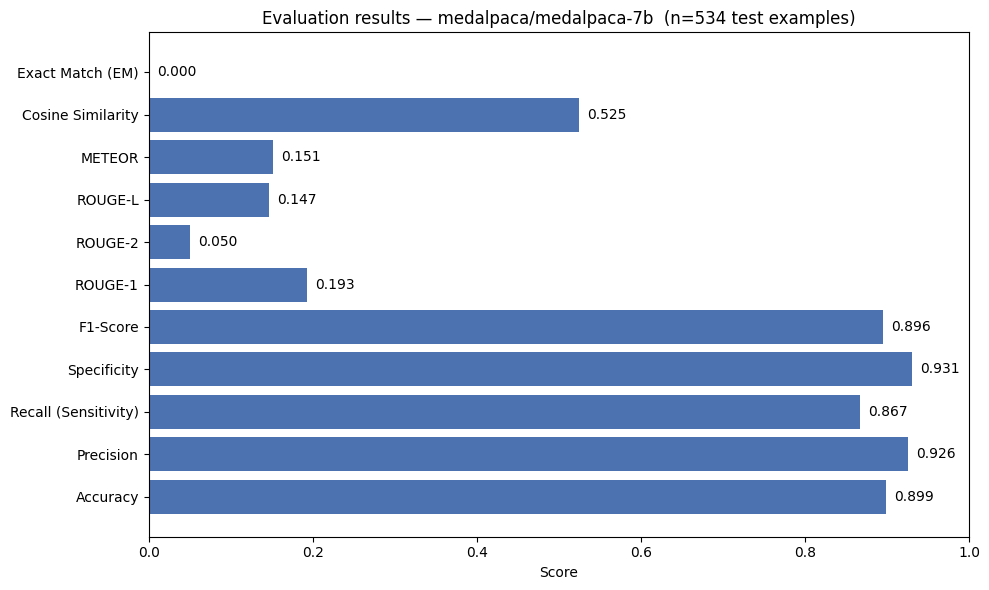

In [19]:
import matplotlib.pyplot as plt

plot_df = summary_df.dropna()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df["Metric"], plot_df["Score"], color="#4C72B0")
ax.set_xlabel("Score")
ax.set_title(f"Evaluation results — {MODEL_REPO}  (n={len(test_data)} test examples)")
ax.set_xlim(0, 1)
for bar, score in zip(bars, plot_df["Score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{score:.3f}", va="center")
plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_results.png", dpi=150)
plt.show()


## 9. Save results

In [20]:
summary_df.to_csv("/kaggle/working/evaluation_summary.csv", index=False)
results_df.to_csv("/kaggle/working/predictions.csv", index=False)

print("Saved:")
print(" - /kaggle/working/evaluation_summary.csv  (metric scores)")
print(" - /kaggle/working/predictions.csv          (per-example predictions vs. references)")
print(" - /kaggle/working/evaluation_results.png   (bar chart)")


Saved:
 - /kaggle/working/evaluation_summary.csv  (metric scores)
 - /kaggle/working/predictions.csv          (per-example predictions vs. references)
 - /kaggle/working/evaluation_results.png   (bar chart)
